In [2]:
!pip install transformers accelerate bitsandbytes sentence-transformers faiss-cpu matplotlib pandas lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 31.1 MB/s eta 0:00:00


In [3]:
import os
import re
import torch
import faiss
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from sklearn.metrics import accuracy_score


In [4]:
# ==========================================
# 1. Global settings (shared benchmark rules)
# ==========================================
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
LLAMA_MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct" # swap in the exact model id if needed
K_RETRIEVAL = 3

In [5]:
import pandas as pd
import xml.etree.ElementTree as ET

# ==========================================
# 2. ABSA 2016 XML parser
# ==========================================
def parse_semeval_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    data = []

    for review in root.findall('.//Review'):
        for sentence in review.findall('.//sentence'):
            text = sentence.find('text').text
            opinions = sentence.find('Opinions')
            if opinions is not None:
                for opinion in opinions.findall('Opinion'):
                    target = opinion.get('target')
                    polarity = opinion.get('polarity')
                    # drop NULL targets and invalid polarities
                    if target != "NULL" and polarity in ["positive", "negative", "neutral"]:
                        data.append({"text": text, "aspect": target, "sentiment": polarity})
    return pd.DataFrame(data)

# ==========================================
# load your uploaded XML file
# ==========================================
# 1. path to the file you uploaded in Colab
dataset_path = '/content/ABSA16_Restaurants_Train_SB1_v2.xml'

# 2. parse XML into a DataFrame
print("Loading dataset from XML...")
df = parse_semeval_xml(dataset_path)
print(f"Successfully loaded {len(df)} aspect-sentiment pairs.")

# 3. (optional) peek at first rows
print(df.head())

# 4. hold out a slice for evaluation
# no separate test file: split from train
from sklearn.model_selection import train_test_split

# 90% RAG index, 10% eval
df_kb, df_test = train_test_split(df, test_size=0.1, random_state=42)
print(f"Knowledge Base size (for RAG): {len(df_kb)}")
print(f"Evaluation Test Set size: {len(df_test)}")

Loading dataset from XML...
Successfully loaded 1880 aspect-sentiment pairs.
                                                text    aspect sentiment
0  Judging from previous posts this used to be a ...     place  negative
1  We, there were four of us, arrived at noon - t...     staff  negative
2  The food was lousy - too sweet or too salty an...      food  negative
3  The food was lousy - too sweet or too salty an...  portions  negative
4                                  Avoid this place!     place  negative
Knowledge Base size (for RAG): 1692
Evaluation Test Set size: 188


In [6]:
# ==========================================
# 3. RAG + FAISS vector store
# ==========================================
print("Loading Embedding Model...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

def build_faiss_index(df_knowledge_base):
    print("Building FAISS Index...")
    # embed text + aspect together for retrieval
    texts_to_embed = [f"Sentence: {row['text']} | Target Aspect: {row['aspect']}" for _, row in df_knowledge_base.iterrows()]
    embeddings = embedding_model.encode(texts_to_embed, convert_to_numpy=True)

    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(embeddings)
    return index, df_knowledge_base

def retrieve_examples(query_text, query_aspect, index, df_kb, k=3):
    query = f"Sentence: {query_text} | Target Aspect: {query_aspect}"
    query_vector = embedding_model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_vector, k)

    retrieved = []
    for idx in indices[0]:
        row = df_kb.iloc[idx]
        retrieved.append({
            "text": row['text'],
            "aspect": row['aspect'],
            "sentiment": row['sentiment']
        })
    return retrieved

Loading Embedding Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
# ==========================================
# 4. Prompt templates (Llama 3 Instruct)
# ==========================================
def format_prompt(method, text, aspect, retrieved_docs=None):
    # strict instruction to keep answers short
    base_instruction = (
        "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
        "Analyze the given sentence and determine the sentiment of the 'Target Aspect'.\n"
        "You MUST output exactly ONE word from these choices: 'positive', 'negative', or 'neutral'. Do not write any explanations or intro text."
    )

    if method == "zero-shot":
        prompt = (
            f"{base_instruction}\n\n"
            f"Sentence: \"{text}\"\n"
            f"Target Aspect: \"{aspect}\""
        )

    elif method == "one-shot":
        prompt = (
            f"{base_instruction}\n\n"
            "Example:\n"
            "Sentence: \"The food was absolutely delicious, but the service was terrible.\"\n"
            "Target Aspect: \"food\"\n"
            "Correct Output: positive\n\n"
            "Now analyze the following:\n"
            f"Sentence: \"{text}\"\n"
            f"Target Aspect: \"{aspect}\""
        )

    elif method == "rag":
        examples_str = "Here are some reference examples:\n"
        for i, doc in enumerate(retrieved_docs):
            examples_str += f"- Sentence: \"{doc['text']}\" | Target Aspect: \"{doc['aspect']}\" | Correct Output: {doc['sentiment']}\n"

        prompt = (
            f"{base_instruction}\n\n"
            f"{examples_str}\n"
            "Now analyze the following:\n"
            f"Sentence: \"{text}\"\n"
            f"Target Aspect: \"{aspect}\""
        )
    return prompt

In [8]:
# ==========================================
# 5. Generation config and output cleanup
# ==========================================
def parse_output(raw_output):
    output_lower = raw_output.lower()
    # match label tokens in model output
    if re.search(r'\bpositive\b', output_lower):
        return "positive"
    elif re.search(r'\bnegative\b', output_lower):
        return "negative"
    elif re.search(r'\bneutral\b', output_lower):
        return "neutral"
    return "unknown"

In [14]:
# ==========================================
# 6. Evaluation loop
# ==========================================
def evaluate_model(df_eval, method, index=None, df_kb=None):
    correct = 0
    total = len(df_eval)

    for i, row in tqdm(df_eval.iterrows(), total=total, desc=f"Evaluating {method}"):
        text, aspect, true_label = row['text'], row['aspect'], row['sentiment']

        retrieved_docs = None
        if method == "rag":
            retrieved_docs = retrieve_examples(text, aspect, index, df_kb, k=K_RETRIEVAL)

        raw_prompt = format_prompt(method, text, aspect, retrieved_docs)

        chat = [{"role": "user", "content": raw_prompt}]
        formatted_input = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(formatted_input, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,  # small buffer so labels are not truncated
                do_sample=False,   # greedy decode; no temperature arg
                pad_token_id=tokenizer.eos_token_id
            )

        generated_tokens = outputs[0][inputs['input_ids'].shape[1]:]
        raw_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        predicted_label = parse_output(raw_answer)

        # debug: print raw output for the first sample only
        if i == df_eval.index[0]:
            print(f"\n[DEBUG {method}] Target: {true_label} | Model Raw Output: '{raw_answer}' | Parsed: {predicted_label}")
        # ---------------------------------------------------------------------------

        if predicted_label == true_label:
            correct += 1

    return (correct / total) * 100

In [ ]:
# ==========================================
# 7. Load LLM and run main eval
# ==========================================
if __name__ == "__main__":
    from huggingface_hub import login

    # --- paste HF token here ---
    # replace the placeholder string below
    HF_TOKEN = "YOUR_API_KEY"
    login(token=HF_TOKEN)

    print("Loading Llama Model...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # model + tokenizer download after auth
    tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        LLAMA_MODEL_ID,
        device_map="auto",
        torch_dtype=torch.float16  # use load_in_4bit=True if VRAM is tight
    )

Loading Llama Model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]


--- Step 1: Loading Dataset ---
Total data: 1880 | Knowledge Base (RAG): 1780 | Test Set: 100

--- Step 2: Building Vector Database for RAG ---
Building FAISS Index...

--- Step 3: Running Evaluations ---


Evaluating zero-shot:   1%|          | 1/100 [00:00<00:09,  9.94it/s]


[DEBUG zero-shot] Target: neutral | Model Raw Output: 'negative' | Parsed: negative


Evaluating zero-shot: 100%|██████████| 100/100 [00:12<00:00,  8.01it/s]


Zero-Shot Accuracy: 84.00%


...

One-Shot Accuracy: 76.00%


Evaluating rag:   1%|          | 1/100 [00:00<00:16,  5.92it/s]


[DEBUG rag] Target: neutral | Model Raw Output: 'negative' | Parsed: negative


Evaluating rag: 100%|██████████| 100/100 [00:18<00:00,  5.42it/s]


RAG (3-Shot) Accuracy: 86.00%

--- Step 4: Plotting Results ---


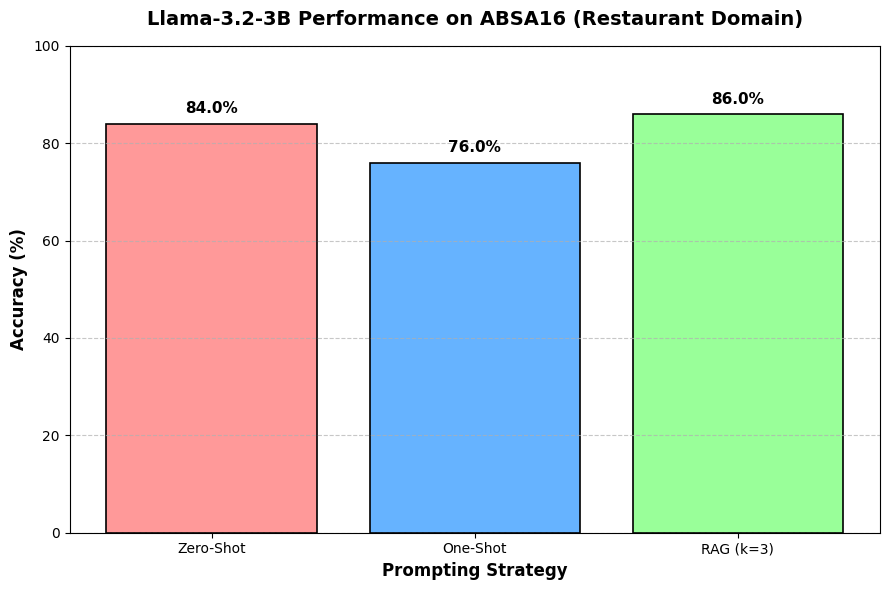

In [16]:
# ==========================================
# sections 7-8: data prep, eval, plotting
# ==========================================
from sklearn.model_selection import train_test_split

print("\n--- Step 1: Loading Dataset ---")
dataset_path = '/content/ABSA16_Restaurants_Train_SB1_v2.xml'
df = parse_semeval_xml(dataset_path)

# data split:
# single train file -> RAG pool + eval holdout
# quick run: evaluate on 100 samples
df_kb, df_test = train_test_split(df, test_size=100, random_state=42)
print(f"Total data: {len(df)} | Knowledge Base (RAG): {len(df_kb)} | Test Set: {len(df_test)}")

print("\n--- Step 2: Building Vector Database for RAG ---")
index, df_kb = build_faiss_index(df_kb)

print("\n--- Step 3: Running Evaluations ---")
# 1. zero-shot eval
acc_zero = evaluate_model(df_test, "zero-shot")
print(f"Zero-Shot Accuracy: {acc_zero:.2f}%")

# 2. one-shot eval
acc_one = evaluate_model(df_test, "one-shot")
print(f"One-Shot Accuracy: {acc_one:.2f}%")

# 3. RAG (3-shot) eval
acc_rag = evaluate_model(df_test, "rag", index=index, df_kb=df_kb)
print(f"RAG (3-Shot) Accuracy: {acc_rag:.2f}%")

# ==========================================
# 8. final accuracy plot
# ==========================================
print("\n--- Step 4: Plotting Results ---")
results = {
    "Zero-Shot": acc_zero,
    "One-Shot": acc_one,
    "RAG (k=3)": acc_rag
}

methods = list(results.keys())
accuracies = list(results.values())

# plot styling
plt.figure(figsize=(9, 6))
bars = plt.bar(methods, accuracies, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black', linewidth=1.2)

# axes and title
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Prompting Strategy', fontsize=12, fontweight='bold')
plt.title('Llama-3.2-3B Performance on ABSA16 (Restaurant Domain)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%",
              ha='center', va='bottom', fontweight='bold', fontsize=11)

# show plot
plt.tight_layout()
plt.show()